In [10]:
import os
import mne

# if Forenzo2023_subject_1_raw.fif already exists, we can load it directly  or download and process the data from the Forenzo2023 dataset
if os.path.exists('Forenzo2023_subject_1_raw.fif'):
    raw = mne.io.read_raw_fif('Forenzo2023_subject_1_raw.fif', preload=True)
    print("Loaded raw data from Forenzo2023_subject_1_raw.fif")
else:
    from moabb.datasets import Forenzo2023
    dataset = Forenzo2023()
    data = dataset.get_data(subjects=[1])
    print(data[1])
    raw = data[1]["0"]["0"]



# save raw to .bdf file
# raw.save('Forenzo2023_subject_1_raw.fif', overwrite=True)


Opening raw data file Forenzo2023_subject_1_raw.fif...
Isotrak not found
    Range : 0 ... 163879 =      0.000 ...   163.879 secs
Ready.
Reading 0 ... 163879  =      0.000 ...   163.879 secs...
Loaded raw data from Forenzo2023_subject_1_raw.fif


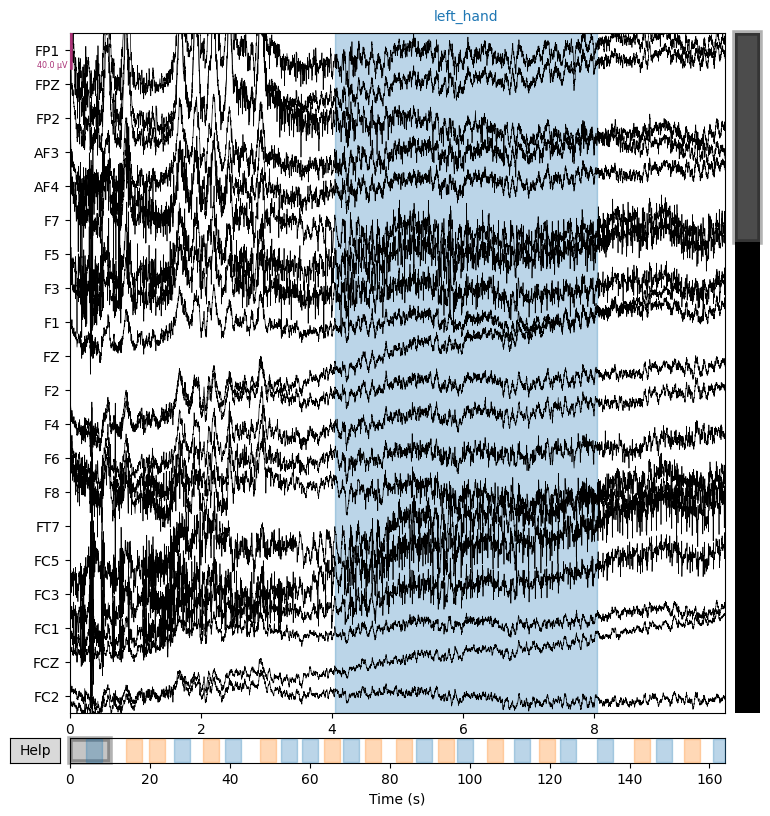

<Info | 11 non-empty values
 bads: []
 ch_names: FP1, FPZ, FP2, AF3, AF4, F7, F5, F3, F1, FZ, F2, F4, F6, F8, ...
 chs: 64 EEG, 1 Stimulus
 custom_ref_applied: False
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 500.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: 1, hand: 1>
>


In [11]:
# avoid having two plots inline
%matplotlib inline

raw.plot()
print(raw.info)

In [12]:
# have a look at annotations
print(raw.annotations)
df_annot = raw.annotations.to_data_frame()
print(df_annot)
print(raw.ch_names)

<Annotations | 25 segments: left_hand (13), right_hand (12)>
                        onset  duration description
0  1970-01-01 00:00:04.041000  4.000000   left_hand
1  1970-01-01 00:00:14.081000  3.999999  right_hand
2  1970-01-01 00:00:19.801001  4.000000  right_hand
3  1970-01-01 00:00:26.000999  4.000000   left_hand
4  1970-01-01 00:00:33.401001  4.000000  right_hand
5  1970-01-01 00:00:38.681000  4.000000   left_hand
6  1970-01-01 00:00:47.601002  4.000000  right_hand
7  1970-01-01 00:00:52.761002  4.000000   left_hand
8  1970-01-01 00:00:58.081001  4.000000   left_hand
9  1970-01-01 00:01:03.640999  4.000000  right_hand
10 1970-01-01 00:01:08.240997  4.000000   left_hand
11 1970-01-01 00:01:13.880997  4.000000  right_hand
12 1970-01-01 00:01:21.640999  4.000000  right_hand
13 1970-01-01 00:01:26.481003  4.000000   left_hand
14 1970-01-01 00:01:32.081001  4.000000  right_hand
15 1970-01-01 00:01:36.841003  4.000000   left_hand
16 1970-01-01 00:01:44.401001  4.000000  right_hand
17 

In [13]:
fs = raw.info['sfreq']

new_fs = 160
# filter to new Nyquist frequency if downsampling (optional but can improve quality when downsampling)
if fs > new_fs:
    """# filter to nyquist """
    # raw.filter(l_freq=0.1, h_freq=new_fs/2 - 1, fir_design='firwin', skip_by_annotation='edge', phase='zero')
    """ filter to alpha-beta range """
    raw.filter(l_freq=8, h_freq=30, fir_design='firwin', skip_by_annotation='edge', phase='zero')

# downsample to 200Hz if original sampling rate is higher (optional but can speed up processing)
if fs > new_fs:
    raw.resample(new_fs)
    fs = new_fs

# keep only eeg channels (remove STI channels)
raw.pick_types(eeg=True, stim=False)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (1.651 s)

Finding events on: STI
25 events found on stim channel STI
Event IDs: [1 2]
Finding events on: STI
25 events found on stim channel STI
Event IDs: [1 2]
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<Raw | Forenzo2023_subject_1_raw.fif, 64 x 26221 (163.9 s), ~12.9 MiB, data loaded>

In [14]:
""" get epochs and create train and test datasets"""
# 3. EPOCHING
# mapping = {'left_hand': '1', 'right_hand': '2'}
# raw.annotations.rename(mapping)
# get events event_id
events, event_id = mne.events_from_annotations(raw,
                                              event_id={'left_hand': 0, 'right_hand': 1})
# 4. EPOCHING 
# Set baseline=None because we handle scaling manually in the next step
epochs = mne.Epochs(raw, events, event_id=event_id, 
                    tmin=0, tmax=4.0, baseline=None, 
                    preload=True, proj=False, verbose=False)

X_raw_data = epochs.get_data(copy=True) 
y_labels = epochs.events[:, -1]



Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


In [15]:
# also create the generated data
import numpy as np
import torch

import sys, os

sys.path.append("../")

from vi_rnn.saving import load_model
import matplotlib.pyplot as plt
from vi_rnn.generate import generate

# Load model
name = "rbm_forenzo_EEG_low_rank_affine_dim_z_3_date_2026_03_29_T_19_56_20"
vae, training_params, task_params = load_model(
    "../models/sweep_eeg/" + name, load_encoder=False, backward_compat=True
)


# 5. TRIAL-WISE Z-SCORING (Manual Baseline/Scaling)
# This replaces the need for MNE's baseline parameter
X_real = np.zeros_like(X_raw_data)
X_gen = np.zeros_like(X_raw_data)
for i in range(X_raw_data.shape[0]):
    trial = X_raw_data[i]
    # Standardize: Mean 0, Std 1 for this specific trial
    # This removes DC offsets and scales amplitude differences
    
    trial_z = (trial - np.mean(trial)) / np.std(trial)
    
    X_real[i] = trial_z

    # generate data for this trial using the VAE
    
    with torch.no_grad():
        # generate data using our fit model
        Z, _, data_gen, rates_gen = generate(
            vae,
            u=None,
            x=torch.from_numpy(trial_z.astype(np.float32)),
            initial_state="posterior_mean",
            k=1,
        )
    data_gen_np = (
    data_gen.squeeze()        # -> (64, n_times)
     .numpy()
    )
    X_gen[i] = data_gen_np



# 5. AUGMENTATION (Split 4s -> 1s)
n_trials, n_channels, n_times = X_real.shape
n_splits = 2
samples_per_split = n_times // n_splits
X_augmented_real = []
X_augmented_gen = []
y_augmented = []
for i in range(n_trials):
    for j in range(n_splits):
        start = j * samples_per_split
        end = (j + 1) * samples_per_split
        X_augmented_real.append(X_real[i, :, start:end])
        X_augmented_gen.append(X_gen[i, :, start:end])
        y_augmented.append(y_labels[i])  # Keep same label for each split  
        

X_augmented_real = np.array(X_augmented_real)
X_augmented_gen = np.array(X_augmented_gen)
y_augmented = np.array(y_augmented)
print("Augmented real data shape:", X_augmented_real.shape)
print("Augmented generated data shape:", X_augmented_gen.shape)
print("Augmented labels shape:", y_augmented.shape)

no out nonlinearity found, setting to identity
using uniform init
Initialising VAE without encoder
Augmented real data shape: (48, 64, 320)
Augmented generated data shape: (48, 64, 320)
Augmented labels shape: (48,)


In [16]:
"""decode with SVM and cross validation """

import mne
import numpy as np
from mne.io import read_raw_edf, concatenate_raws
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from mne.decoding import CSP


cv_split = 5


pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='linear', random_state=42))])
cv = StratifiedKFold(n_splits= cv_split, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_augmented_real.reshape(X_augmented_real.shape[0], -1), y_augmented, cv=cv)
print("Cross-validation scores:", scores)
print("Mean CV score:", np.mean(scores) , "+/-", np.std(scores))


Cross-validation scores: [0.6        0.6        0.4        0.55555556 0.44444444]
Mean CV score: 0.5200000000000001 +/- 0.082671445501059


In [17]:
# do same with generated data
scores_gen = cross_val_score(pipe, X_augmented_gen.reshape(X_augmented_gen.shape[0], -1), y_augmented, cv=cv)
print("Cross-validation scores (generated data):", scores_gen)
print("Mean CV score (generated data):", np.mean(scores_gen) , "+/-", np.std(scores_gen))

Cross-validation scores (generated data): [0.5        0.4        0.4        0.44444444 0.66666667]
Mean CV score (generated data): 0.4822222222222222 +/- 0.09928136846083854


In [18]:
""" do the same with riemmanian geometry and tangent space mapping """
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

cov = Covariances(estimator='lwf')
ts = TangentSpace()
pipe_riemann = Pipeline([('cov', cov), ('ts', ts), ('svc', SVC(kernel='linear', random_state=42))])
scores_riemann = cross_val_score(pipe_riemann, X_augmented_real, y_augmented, cv=cv)
print("Riemannian Cross-validation scores:", scores_riemann)
print("Mean Riemannian CV score:", np.mean(scores_riemann) , "+/-", np.std(scores_riemann))

Riemannian Cross-validation scores: [0.8        0.8        0.7        0.77777778 1.        ]
Mean Riemannian CV score: 0.8155555555555555 +/- 0.09928136846083857


In [19]:
# same with generated data
scores_riemann_gen = cross_val_score(pipe_riemann, X_augmented_gen, y_augmented, cv=cv)
print("Riemannian Cross-validation scores (generated data):", scores_riemann_gen)
print("Mean Riemannian CV score (generated data):", np.mean(scores_riemann_gen) , "+/-", np.std(scores_riemann_gen))

Riemannian Cross-validation scores (generated data): [0.9        0.5        0.4        0.44444444 0.77777778]
Mean Riemannian CV score (generated data): 0.6044444444444445 +/- 0.19784018990271096
